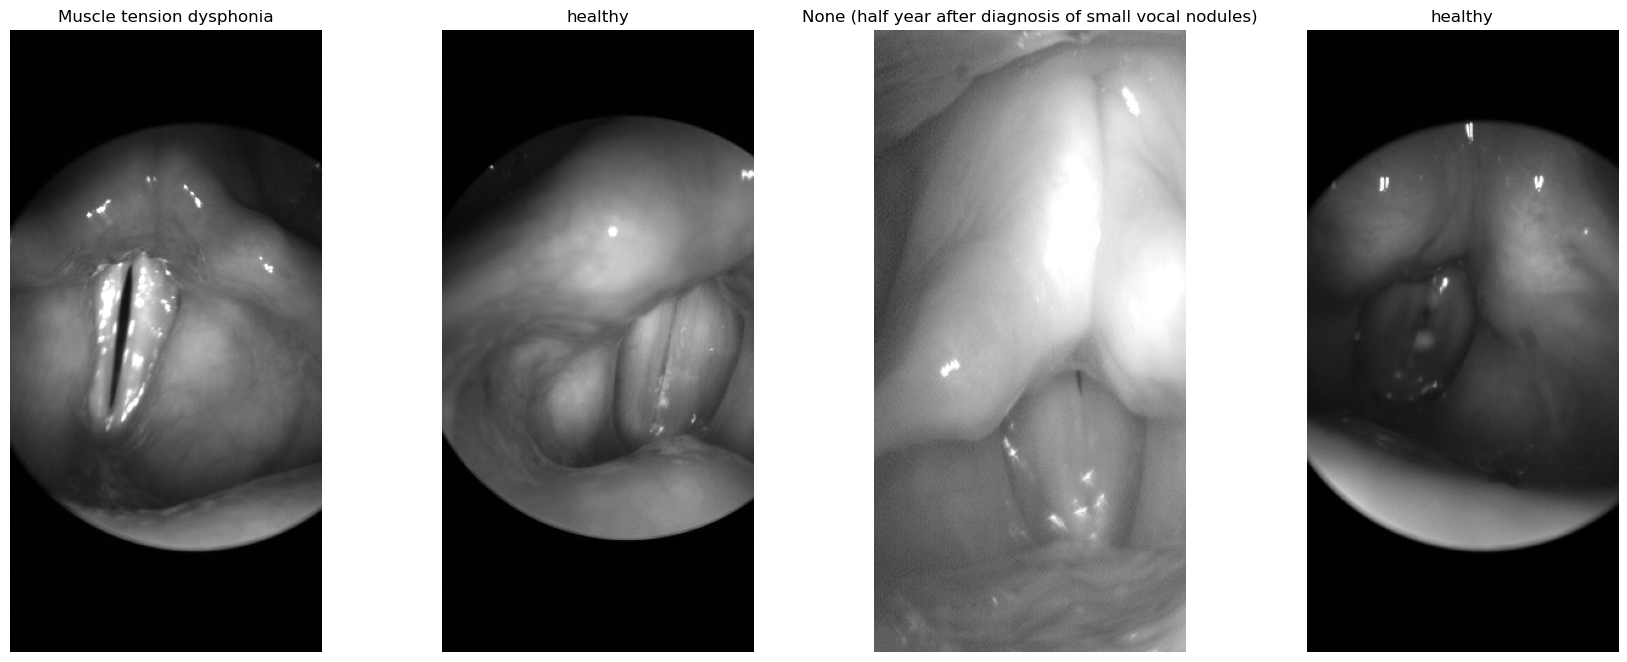

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from PIL import Image
folder_path = r"C:\Users\aditya\Desktop\Mini_BAGLS_dataset"
image_files = ["15.png","20.png","31.png","47.png"]
mask_files = ["15_seg.png","20_seg.png","31_seg.png","47_seg.png"]
metadata_files = ["15.meta","20.meta","31.meta","47.meta"]
fig, axes = plt.subplots(1, 4, figsize=(17.5, 7.5))
image_list = []
mask_list = []
metadata_list = [] 
for i in range(len(image_files)):
    image=Image.open(os.path.join(folder_path,image_files[i]))
    mask=Image.open(os.path.join(folder_path, mask_files[i]))
    with open(os.path.join(folder_path, metadata_files[i]),'r') as f:
        metadata = json.load(f)
    image_list.append(image)
    mask_list.append(mask)
    metadata_list.append(metadata)
    image = image.resize((256,512))
    mask = mask.resize((256,512))
    image_array = np.array(image)
    overlay = image_array.copy()
    mask = np.array(mask)
    overlay[mask > 0] = [255, 0, 0]
    combined_image = np.clip((0.6 * image_array + 0.4 * overlay), 0, 255).astype(np.uint8)
    disorder_status = metadata.get("Subject disorder status", "Unknown")
    axes[i].imshow(image_array)
    axes[i].set_title(f"{disorder_status}")
    axes[i].axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


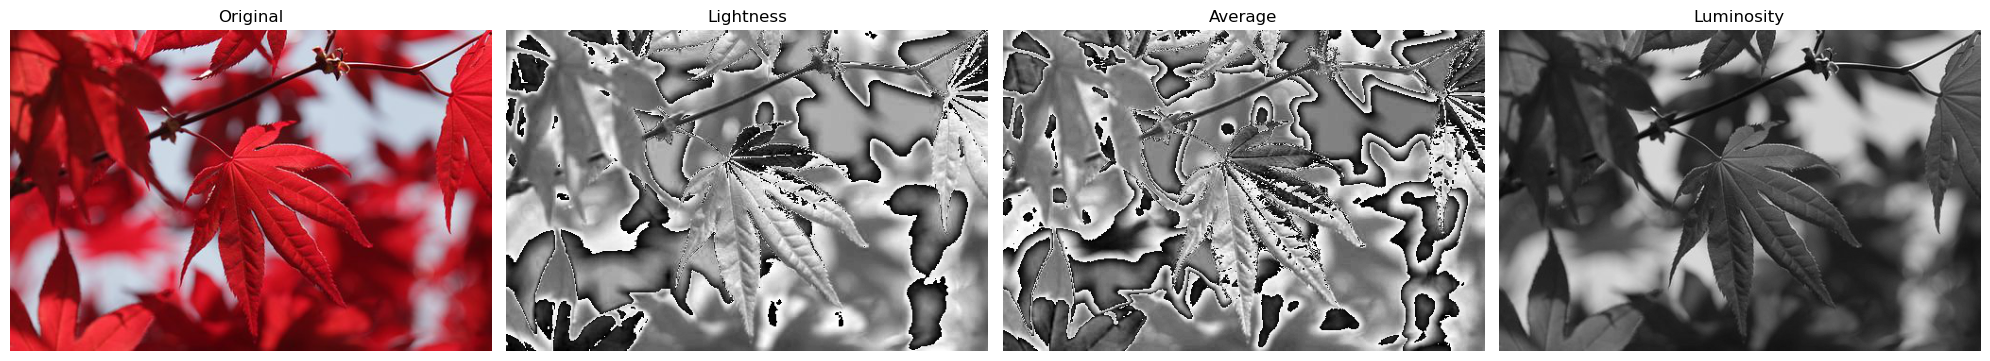

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the image as an RGB image
image_path = "C:\MS\Germany\List of universities\FAU Erlangen\Semester 2\Data Science Survival Skills\Homework submission\Homework 3\leaves.jpg"  # Replace with your actual path
image = Image.open(image_path).convert('RGB')
image_array = np.array(image)

# Lightness Method
def lightness_method(img):
    return ((np.max(img, axis=2) + np.min(img, axis=2)) / 2).astype(np.uint8)

# Average Method
def average_method(img):
    return ((img[:, :, 0] + img[:, :, 1] + img[:, :, 2]) / 3).astype(np.uint8)

# Luminosity Method
def luminosity_method(img):
    return (0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]).astype(np.uint8)

# Apply the three methods
lightness = lightness_method(image_array)
average = average_method(image_array)
luminosity = luminosity_method(image_array)

# Plot the original and grayscale images using subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_array)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(lightness, cmap='gray')
axes[1].set_title('Lightness')
axes[1].axis('off')

axes[2].imshow(average, cmap='gray')
axes[2].set_title('Average')
axes[2].axis('off')

axes[3].imshow(luminosity, cmap='gray')
axes[3].set_title('Luminosity')
axes[3].axis('off')

plt.tight_layout()
plt.show()
